In [1]:
import numpy as np
import matplotlib.pyplot as plt

Wir wollen eine Funktion f mit fourier annähern:

$f = \sin(2\pi 4t)+e^{2\pi 3kt}$

In [ ]:
f = lambda t: np.sin(2 * np.pi * 4 * t) + np.exp(2j * np.pi * 3 * t)

Nun messen wir f an $n$ Stellen - so können wir Frequenzen zwischen $-\frac{N}{2}$ und $\frac{N}{2}-1$ erkennen.

In [47]:
n = 40
t = np.linspace(0, 1, n)
y = f(t)
k = np.arange(n) # y ist so angeordnet

Für illustrative Zwecke können wir den Messwerten $\begin{bmatrix}y_0&y_1&...&y_{N-1}\end{bmatrix}$ einen kleinen Fehler hinzufügen:

In [43]:
y += (np.random.rand(n) - 0.5) * 0.1

Die Fourier-Koeffizienten berechnen wir jetzt mit `np.fft.fft`. Wir plotten diese, um eine 

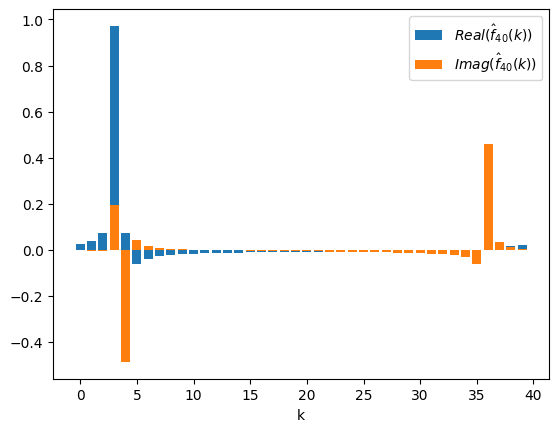

In [48]:
c = np.fft.fft(y) / n

plt.bar(k, c.real, label=r"$Real(\hat{f}_{%s}(k))$" % (n))
plt.bar(k, c.imag, label=r"$Imag(\hat{f}_{%s}(k))$" % (n))
plt.xlabel("k")
plt.legend()

Wir beobachten: 
- für $k=4$ hatten wir eine Sinuswelle, die als reeller Oszillator aus zwei komplexen Schwingungen besteht (an positionen $4$ und $N-4$)
- für $k=3$ hatten wir einen einzelnen exponentiellen Oszillator - dieser schlägt nur einmal aus. 

## Zero-Padding
Wenn wir diese Funktion nun an mehr als $n$ Stellen auswerten wollen, können wir das tun, indem wir den **mittleren frequenzen** einige nullen hinzufügen. <br> Wir setzen ein neues $N_2$ fest - an so vielen Stellen möchten wir auswerten. 

(Siehe oben. Die Frequenzen um $\frac{N}{2}$ haben die schwächsten Amplituden - Dies nutzen wir aus.)



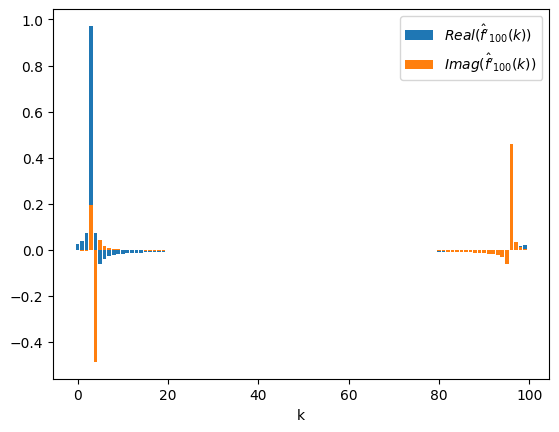

In [49]:
N2 = 100
K2 = np.arange(N2)

# Übertrage rand-Frequenzen, lasse Mitte gleich null
C = np.zeros(N2, dtype=complex)
C[:n//2] = c[:n//2]
C[N2-n//2:] = c[n-n//2:]

# Plot
plt.bar(K2, C.real, label=r"$Real(\hat{f}'_{%s}(k))$" % (N2))
plt.bar(K2, C.imag, label=r"$Imag(\hat{f}'_{%s}(k))$" % (N2))
plt.xlabel("k")
plt.legend()

Somit haben wir ein neues Frequenzspektrum, dass für $N_2$ Messstellen dieselben Schwingungen produziert, die wir ursprünglich gemessen haben. Testen wir es aus, indem wir zurücktransformieren:

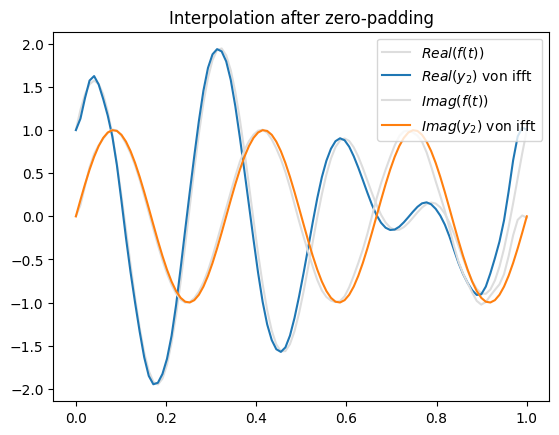

In [50]:
Y2 = np.fft.ifft(C) * N2
T2 = np.linspace(0, 1, N2)

plt.title("Interpolation after zero-padding")
plt.plot(T2, f(T2).real, color="#dddddd", label=r"$Real(f(t))$")
plt.plot(T2, Y2.real, label=r"$Real(y_2)$ von ifft")

plt.plot(T2, Y2.imag, color="#dddddd", label=r"$Imag(f(t))$")
plt.plot(T2, f(T2).imag, label=r"$Imag(y_2)$ von ifft")
plt.legend()
plt.show()

Damit haben wir eine sehr gute Annäherung an die ursprüngliche Funktion. 